In [2]:

import import_ipynb
import nbimporter
from utils import prepareTrainingSet3Sec,standardization,metrics,Grafico_Before_After_Standardization,Grafico_Before_After_GridSearch,Grafico_Tre_Valori,evaluate_Model, encode_labels# type: ignore


from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score



In [13]:

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
# Creare il modello SVM
model = SVC(kernel='rbf', C=0.9, gamma='scale')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)
before_standardization=accuracy_score(y_test, y_pred)
y_pred_train = model.predict(X_train)
evaluate_Model(y_test, y_pred,y_train, y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.2923
Precision: 0.2401
Recall: 0.2937
F1-score: 0.2365
F2-score: 0.2645
---------STATISTICHE TRAING----------
Accuratezza: 0.2874
Precision: 0.2599
Recall: 0.2870
F1-score: 0.2337
F2-score: 0.2597

=== Analisi ===
Il modello potrebbe soffrire di UNDERFITTING (performance bassa su entrambi i set).


In [12]:

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
X_train, X_test= standardization(X_train, X_test)

# Creare il modello SVM
model = SVC(kernel='rbf', C=0.9, gamma='scale')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)
after_standardization=accuracy_score(y_test, y_pred)
y_pred_train = model.predict(X_train)
evaluate_Model(y_test, y_pred,y_train, y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.8544
Precision: 0.8532
Recall: 0.8537
F1-score: 0.8522
F2-score: 0.8528
---------STATISTICHE TRAING----------
Accuratezza: 0.9158
Precision: 0.9166
Recall: 0.9158
F1-score: 0.9158
F2-score: 0.9157

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


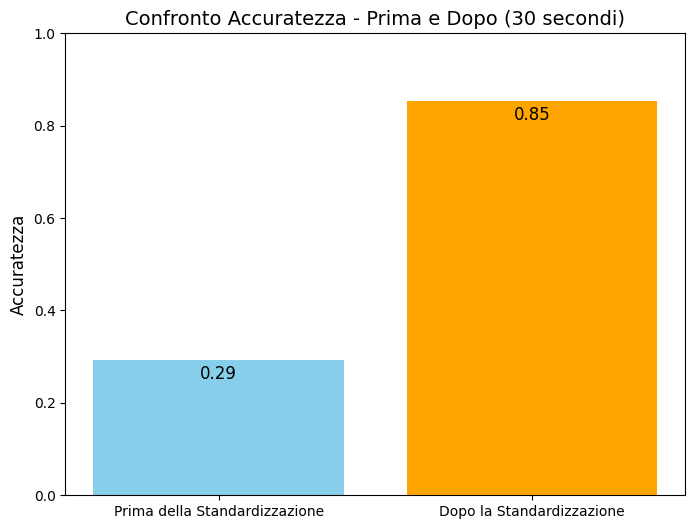

In [4]:
Grafico_Before_After_Standardization(before_standardization, after_standardization)

In [9]:
# Permette di testare diverse configurazioni iperparametriche 
param_grid = {
    'C': [1, 10],
    'gamma': ['scale'] + [0.1,1],
    'kernel': ['rbf','poly']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("I Migliori parametri trovati sono:", grid_search.best_params_)
best_model = grid_search.best_estimator_

I Migliori parametri trovati sono: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [8]:
# Supponiamo che prepareTrainingSet3Sec, encode_labels e standardization siano definite altrove
X_train, X_test, y_train, y_test = prepareTrainingSet3Sec()
X_train, X_test = standardization(X_train, X_test)

# Definisci il modello
model = SVC()

# Definisci la griglia dei parametri per GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Esegui GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Filtra i modelli con differenza di accuracy entro il 10%
valid_models = []
for params in grid_search.cv_results_['params']:
    model.set_params(**params)
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    if abs(train_accuracy - test_accuracy) <= 0.10 and train_accuracy < 0.99:
        valid_models.append((model, params, train_accuracy, test_accuracy))

# Trova il miglior modello tra quelli validi
if valid_models:
    best_model, best_params, best_train_accuracy, best_test_accuracy = max(valid_models, key=lambda x: x[3])
    print(f"Training Accuracy: {best_train_accuracy}")
    print(f"Testing Accuracy: {best_test_accuracy}")
    print(f"Best Parameters: {best_params}")
    print("La differenza tra l'accuracy di training e di test è entro il 10%.")
else:
    print("Nessun modello ha una differenza di accuracy entro il 10%.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


KeyboardInterrupt: 

In [11]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
X_train, X_test= standardization(X_train, X_test)

# Creare il modello SVM
model = SVC(kernel='rbf', C=5, gamma='scale')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)
after_grid=accuracy_score(y_test, y_pred)
y_pred_train = model.predict(X_train)
evaluate_Model(y_test, y_pred,y_train, y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.9249
Precision: 0.9245
Recall: 0.9241
F1-score: 0.9239
F2-score: 0.9239
---------STATISTICHE TRAING----------
Accuratezza: 0.9865
Precision: 0.9865
Recall: 0.9865
F1-score: 0.9865
F2-score: 0.9865

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


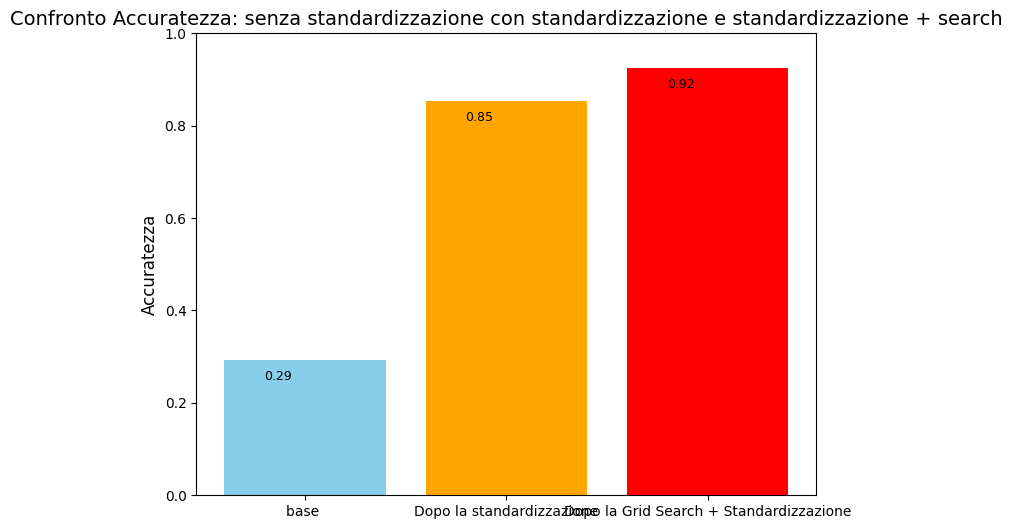

In [14]:
Grafico_Tre_Valori(before_standardization, after_standardization, after_grid)

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# 1. Calcola la cross-validation sul set di training
model = SVC(C=0.3, kernel='rbf')
cross_val_scores = cross_val_score(model, X_train, y_train, cv=10)

# 2. Calcola l'accuratezza sul set di training
model.fit(X_train, y_train)
training_accuracy = model.score(X_train, y_train)

# 3. Calcola la media dei punteggi della cross-validation
cv_accuracy = cross_val_scores.mean()

# 4. Confronta i risultati
print("Accuratezza media della cross-validation:", cv_accuracy)
print("Accuratezza sul training set:", training_accuracy)

# Analisi diagnostica
print("\n=== Analisi ===")
if abs(training_accuracy - cv_accuracy) > 0.05:  # Scarto percentuale del 5%
    print("Il modello potrebbe soffrire di OVERFITTING (performance molto migliore sul training set).")
else:
    print("Il modello sembra bilanciato e generalizza bene.")

Accuratezza media della cross-validation: 0.7760242490613266
Accuratezza sul training set: 0.8243243243243243

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.
